# AB Aur: pipeline vs commissioning notebook

Runs the same 92 frames as the commissioning notebook
(`working-ab-aur_07022026.ipynb`, 2025-12-07 L') through **this** pipeline and
compares the median Q_phi / U_phi against its saved reference.

It follows the same shape as `examples/process_polmode.py`, so the steps line
up one for one -- config, load, geometry, cycles, fast axis + IP, Stokes,
products -- except that the last step is a comparison rather than a write.

Two bookkeeping differences from the notebook, both handled by fitting a
single scale factor: it omits the ½ factors in the double differences (so its
Q/U/I are 2x ours) and its Q_phi uses the opposite sign convention.

## 0. Config

The same knobs as `process_polmode.py`. Both are pinned here rather than
chosen, because this is a comparison against a fixed reference: fitting the
offset would compare the pipeline against a moving target, and the notebook
applied no leakage correction.

In [2]:
import glob, logging, os, sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from instruments.nirc2 import NIRC2PolarimetryData
from polarimetry import (build_stokes_cubes, fit_ip_uphi, fit_ip_uphi_all,
                         mean_ip, median_stokes_cube, radial_stokes)
from reduction import fit_beam_geometry
from utils import crop, frame_number, load_frames

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")
log = logging.getLogger("compare_ab_aur")

DATA_DIR = "/home/shared/exoserver/NIRC2_Pol/jaykes_reduction/2025-12-07/reduced"
NOTEBOOK_DIR = os.path.expanduser("~/AB-Aur")

# the notebook's frame selection, as three disjoint runs
FRAME_RANGES = [(857, 900), (915, 930), (932, 963)]

FAST_AXIS_METHOD = "fixed"        # compare at a pinned offset
THETA_OFF = -13             # the notebook's own value
IP_METHOD = None                  # the notebook applied none

REGISTER_METHOD = "min"           # AB Aur's core is saturated
BKG_BOX = (25, 350, 50, 400)      # the notebook's per-beam mean box
CROP = 400                        # the notebook's cutout size
IP_MASK_RADIUS = 22

## 1. The instrument

One subclass, carrying only the per-dataset choices — here just the
background — exactly as `process_polmode.py` defines `NightPolData`.

In [3]:
class ABAurData(NIRC2PolarimetryData):
    """NIRC2-Pol as configured for this night."""

    background_method = "mean_box"
    background_box = BKG_BOX


instrument = ABAurData()

## 2. Load and select

These frames are already reduced, so there is no dark/flat step — the
comparison starts from the notebook's own reduced products. `frame_number`
reads the observation number out of each filename, and `FRAME_RANGES` picks
the notebook's three runs.

In [4]:
def wanted(path):
    n = frame_number(path)
    return n is not None and any(lo <= n <= hi for lo, hi in FRAME_RANGES)


files = sorted(f for f in glob.glob(os.path.join(DATA_DIR, "reduced*.fits"))
               if wanted(f))
frames = load_frames(files)
print(f"{len(frames)} frames")

92 frames


## 3. Beam geometry

Measured from the data every time. The separation moves between epochs and
nothing downstream can undo a wrong value, so `split_beams` refuses until
this has run.

In [5]:
instrument.top_row_start, instrument.beam_x_offset = fit_beam_geometry(
    instrument, frames)
print("beam geometry:", instrument.top_row_start, instrument.beam_x_offset)

INFO beam geometry measured from 92 frame(s): top_row_start=505.05, beam_x_offset=12.63 (scatter 0.57, 0.08 px)
WARNING Measured beam_x_offset = 12.63 sits between pixels, so rounding either way leaves about half a pixel of beam misalignment. Compare both by reducing with each and seeing which gives less U_phi.


beam geometry: 505 13


## 4. HWP cycles

In [6]:
cycles = instrument.match_modulator_cycles(frames)
print(f"{len(cycles)} complete cycles")

INFO Matched 23 complete modulator cycles


23 complete cycles


## 5. Fast axis offset and instrumental polarization

The same two choices `process_polmode.py` makes, and in the same order: an
`edge_annulus_*` leakage needs no offset so it could be measured first, while
`fit_uphi_*` needs the offset as input. Here the offset is pinned and IP is
off, so both are one-liners — change `IP_METHOD` above to try a route.

In [14]:
theta_off = THETA_OFF
IP_METHOD = "fit_uphi_all"

if IP_METHOD == "fit_uphi_all":
    ip = fit_ip_uphi_all(instrument, cycles, theta_off,
                         mask_radius=IP_MASK_RADIUS, crop_size=CROP,
                         register_method=REGISTER_METHOD)
elif IP_METHOD == "fit_uphi_per_cycle":
    ip = [fit_ip_uphi(instrument, c, theta_off, mask_radius=IP_MASK_RADIUS,
                      crop_size=CROP, register_method=REGISTER_METHOD)
          for c in cycles]
    print("mean:", mean_ip(ip).describe())
elif IP_METHOD is not None:
    raise ValueError(f"this notebook handles None, fit_uphi_all and "
                     f"fit_uphi_per_cycle; got {IP_METHOD!r}")

print(f"theta_off = {theta_off} deg, IP = {IP_METHOD}")

INFO All-cycle U_phi-minimization IP over 23 cycles: ipq=-0.00511 ipu=-0.00514 (0.724% at 112.6deg) method=uphi_min scope=sequence_joint | pooled U_phi std 23.56 -> 23.22


theta_off = -13 deg, IP = fit_uphi_all


## 6. Stokes cubes

In [15]:
cubes = build_stokes_cubes(instrument, cycles, fast_axis_offset=theta_off,
                           register_method=REGISTER_METHOD, ip=ip)
med = median_stokes_cube(cubes)
print("median cube:", med.shape)

median cube: (3, 450, 1011)


/home/blewis/NIRC2Pol-DPP/examples/../polarimetry/stokes.py:424: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(np.asarray(stokes_cubes), axis=0)


## 7. Crop, and find the star

`crop` quantises its origin, so the star does **not** land exactly on the
centre of the cutout — it is up to a pixel out. Carry that offset through and
tell `radial_stokes` where the star actually is: a pixel of error there leaks
disk signal straight into U_phi.

In [9]:
ny, nx = med[1].shape
star = ((ny - 1) / 2, (nx - 1) / 2)          # where registration puts it

I, sr, sc = crop(med[0], (CROP, CROP), center=star)
Q, _, _ = crop(med[1], (CROP, CROP), center=star)
U, _, _ = crop(med[2], (CROP, CROP), center=star)

star_in_crop = (star[0] - sr, star[1] - sc)
qphi, uphi = radial_stokes(Q, U, center=star_in_crop)
print(f"star sits at {star_in_crop} in the {CROP}x{CROP} crop")

star sits at (200.5, 200.0) in the 400x400 crop


## 8. Compare against the notebook

The notebook's star sits at (203, 197) in its own cutouts, so its images are
shifted onto ours before any pixelwise statistic. The scale factor is fitted,
absorbing both the missing ½ factors and the sign convention.

In [16]:
from utils.imutils import translate

nb_qphi = fits.getdata(os.path.join(NOTEBOOK_DIR, "qphi_median.fits"))
nb_uphi = fits.getdata(os.path.join(NOTEBOOK_DIR, "uphi_median.fits"))
nb_c = (203.0, 197.0)

nb_qphi_al = translate(np.nan_to_num(nb_qphi), star_in_crop[0] - nb_c[0],
                       star_in_crop[1] - nb_c[1])
nb_uphi_al = translate(np.nan_to_num(nb_uphi), star_in_crop[0] - nb_c[0],
                       star_in_crop[1] - nb_c[1])

yy, xx = np.mgrid[:CROP, :CROP]
r = np.hypot(yy - star_in_crop[0], xx - star_in_crop[1])
ann = (r > 22) & (r < 150)

sel = ann & np.isfinite(qphi) & np.isfinite(nb_qphi_al) & (nb_qphi_al != 0)
a, b = qphi[sel], nb_qphi_al[sel]
scale = float(np.nansum(a * b) / np.nansum(a * a))
corr = float(np.corrcoef(a, b)[0, 1])

print(f"correlation      {corr:.4f}")
print(f"fitted scale     {scale:.3f}   (expect ~2 from the missing 1/2 factors)")
print(f"residual std     {np.nanstd(b - scale * a) / np.nanstd(b):.3f}")
print(f"U_phi std ratio  {np.nanstd(uphi[sel]) / np.nanstd(nb_uphi_al[sel]):.3f}")

correlation      0.9731
fitted scale     1.863   (expect ~2 from the missing 1/2 factors)
residual std     0.230
U_phi std ratio  0.244


## 9. Look at it

U_phi is the null channel: if it is comparable to Q_phi there is no
detection, however good the image looks.

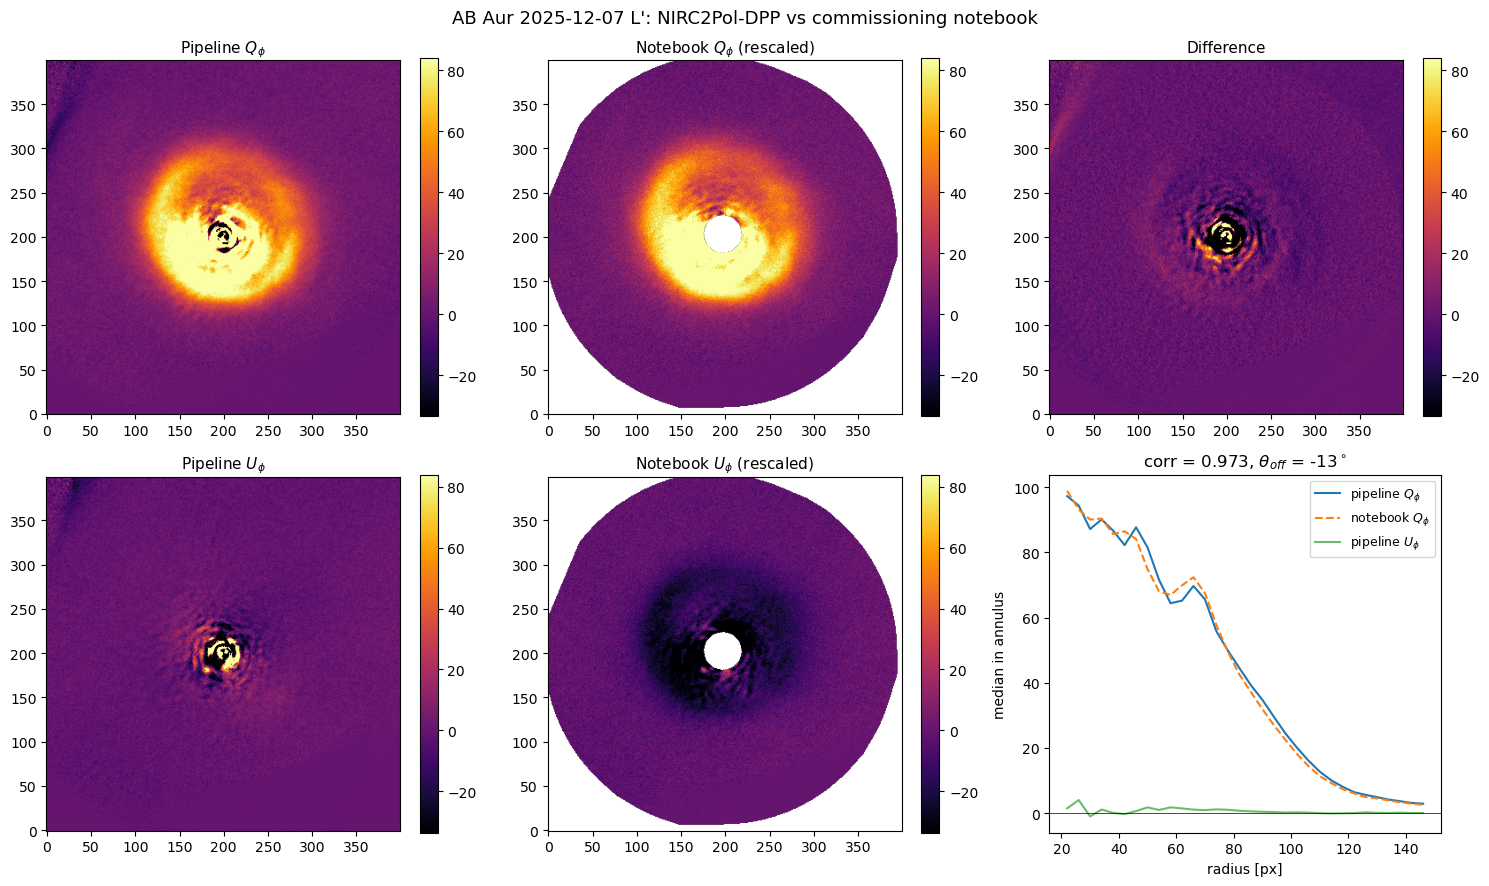

In [18]:
v = np.nanstd(b) / abs(scale)
nb_scaled = np.sign(scale) * nb_qphi / abs(scale)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
panels = [(ax[0, 0], qphi, "Pipeline $Q_\\phi$"),
          (ax[0, 1], nb_scaled, "Notebook $Q_\\phi$ (rescaled)"),
          (ax[0, 2], np.sign(scale) * nb_qphi_al / abs(scale) - qphi,
           "Difference"),
          (ax[1, 0], uphi, "Pipeline $U_\\phi$"),
          (ax[1, 1], np.sign(scale) * nb_uphi / abs(scale),
           "Notebook $U_\\phi$ (rescaled)")]
for a_, img, title in panels:
    im = a_.imshow(img, origin="lower", vmin=-v, vmax=2.5 * v, cmap="inferno")
    a_.set_title(title, fontsize=11)
    fig.colorbar(im, ax=a_, fraction=0.046)

bins = np.arange(22, 150, 4)
prof = lambda img: [np.nanmedian(img[(r >= lo) & (r < lo + 4)]) for lo in bins]
ax[1, 2].plot(bins, prof(qphi), label="pipeline $Q_\\phi$")
ax[1, 2].plot(bins, prof(np.sign(scale) * nb_qphi_al / abs(scale)), "--",
              label="notebook $Q_\\phi$")
ax[1, 2].plot(bins, prof(uphi), label="pipeline $U_\\phi$", alpha=0.7)
ax[1, 2].axhline(0, color="k", lw=0.5)
ax[1, 2].set_xlabel("radius [px]"); ax[1, 2].set_ylabel("median in annulus")
ax[1, 2].set_title(f"corr = {corr:.3f}, $\\theta_{{off}}$ = {theta_off}$^\\circ$")
ax[1, 2].legend(fontsize=9)

fig.suptitle("AB Aur 2025-12-07 L': NIRC2Pol-DPP vs commissioning notebook",
             fontsize=13)
fig.tight_layout()